# Step 1: Domain Split Assignment

**Goal:** Assign batches to source/target for both split criteria

**Tasks:**
- [x] Implement Split 1 (control mode) assignment
- [x] Implement Split 2 (clustering)
- [ ] Visualize cluster separation (PCA/t-SNE)
- [ ] Check overlap between Split 1 and Split 2

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from src.data_loader import load_batches, get_batch_info
from src.domain_splits import (
    get_control_mode_split,
    get_clustering_split,
    compute_split_overlap,
    save_split_assignments,
)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Control Mode Split (Split 1)

In [3]:
# Get control mode splits
split_1a = get_control_mode_split("1a")
split_1b = get_control_mode_split("1b")
split_1c = get_control_mode_split("1c")

print("Split 1a: Recipe vs Operator")
print(f"  Source: {len(split_1a['source'])} batches (1-30)")
print(f"  Target: {len(split_1a['target'])} batches (31-60)")

print("\nSplit 1b: Recipe vs APC [PRIMARY]")
print(f"  Source: {len(split_1b['source'])} batches (1-30)")
print(f"  Target: {len(split_1b['target'])} batches (61-90)")

print("\nSplit 1c: Recipe+Operator vs APC")
print(f"  Source: {len(split_1c['source'])} batches (1-60)")
print(f"  Target: {len(split_1c['target'])} batches (61-90)")

Split 1a: Recipe vs Operator
  Source: 30 batches (1-30)
  Target: 30 batches (31-60)

Split 1b: Recipe vs APC [PRIMARY]
  Source: 30 batches (1-30)
  Target: 30 batches (61-90)

Split 1c: Recipe+Operator vs APC
  Source: 60 batches (1-60)
  Target: 30 batches (61-90)


## 2. Clustering Split (Split 2)

In [4]:
# Load batches and compute clustering split
batches = load_batches()
cluster_result = get_clustering_split(batches, exclude_faults=True)

print("Clustering Split (k-means on early-window features)")
print(f"  Source: {len(cluster_result['source'])} batches")
print(f"  Target: {len(cluster_result['target'])} batches")
print(f"\n  Source batches: {cluster_result['source']}")
print(f"  Target batches: {cluster_result['target']}")

Clustering Split (k-means on early-window features)
  Source: 71 batches
  Target: 19 batches

  Source batches: [1, 2, 3, 4, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 56, 57, 58, 60, 61, 62, 63, 64, 65, 66, 68, 69, 70, 72, 73, 74, 76, 78, 79, 80, 82, 83, 84, 86, 88, 89, 90]
  Target batches: [5, 11, 13, 15, 17, 19, 27, 35, 37, 53, 55, 59, 67, 71, 75, 77, 81, 85, 87]


In [6]:
# View clustering features
features_df = cluster_result['features']
features_df.head(10)

,DO2_mean,DO2_std,DO2_min,Fs_mean,Fs_std,Fs_slope,batch_id,cluster
0,12.943042,1.077257,9.8146,49.145390,33.919889,1.138790,1,0
1,12.671537,1.157304,9.1854,49.543554,33.755249,1.118881,2,0
2,11.175239,1.535594,6.3812,54.360231,32.490104,1.098266,3,0
3,11.691095,1.434850,7.6010,49.543554,33.755249,1.118881,4,0
4,12.151207,1.319963,8.8033,45.856502,37.426409,1.103604,5,1
5,11.761683,1.459848,7.4467,49.543554,33.755249,1.118881,6,0
6,12.761424,1.094077,9.2017,49.775862,33.656644,1.107266,7,0
7,11.807696,1.250146,8.2509,49.543554,33.755249,1.118881,8,0
8,12.571613,1.161924,9.3746,51.730159,32.974709,1.082803,9,0
9,12.694607,1.100801,9.0936,49.543554,33.755249,1.118881,10,0


## 3. Visualize Cluster Separation

In [16]:
# Prepare features for visualization
feature_cols = ['DO2_mean', 'DO2_std', 'DO2_min', 'Fs_mean', 'Fs_std', 'Fs_slope']
X = features_df[feature_cols].values

# Add control mode labels for comparison
batch_info = get_batch_info(batches)
features_df = features_df.merge(batch_info[['batch_id', 'control_mode', 'p_conc']], on='batch_id')

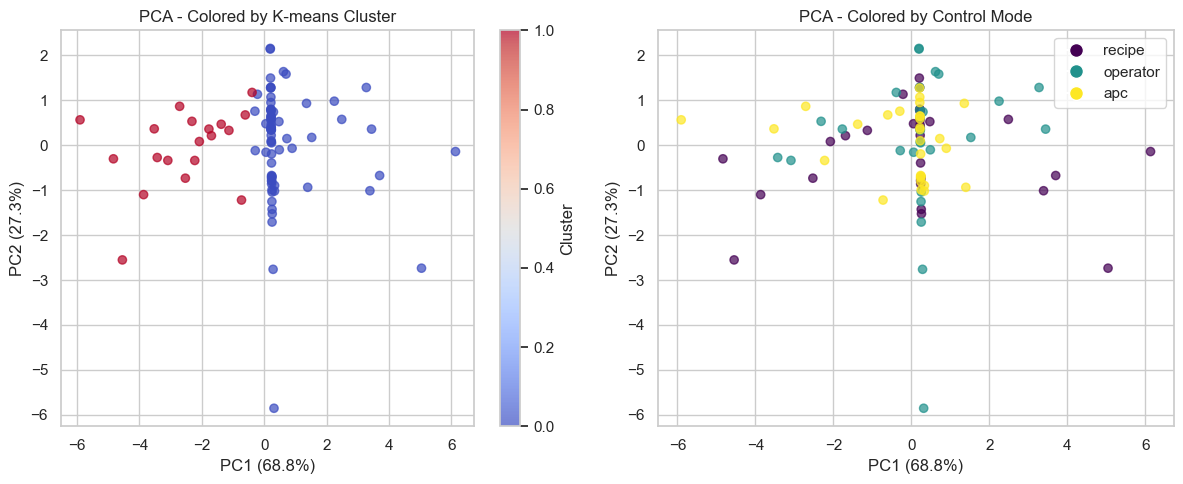

In [8]:
# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Color by cluster
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=features_df['cluster'], cmap='coolwarm', alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA - Colored by K-means Cluster')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Color by control mode
mode_colors = {'recipe': 0, 'operator': 1, 'apc': 2}
colors = features_df['control_mode'].map(mode_colors)
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap='viridis', alpha=0.7)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA - Colored by Control Mode')

# Add legend for control modes
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.viridis(i/2), 
                          label=m, markersize=10) for m, i in mode_colors.items()]
axes[1].legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.savefig('../outputs/figures/pca_clusters.png', dpi=150)
plt.show()

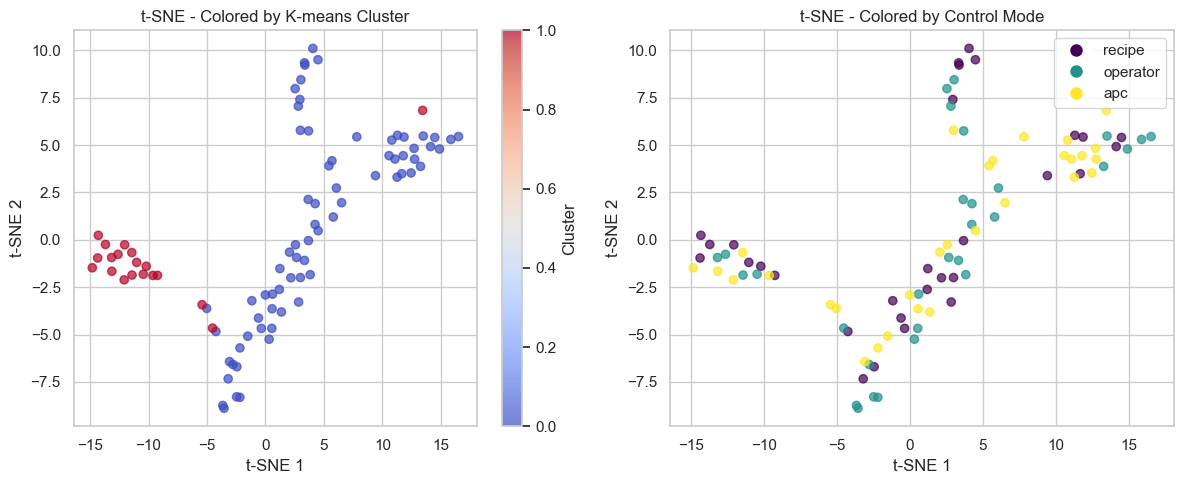

In [9]:
# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Color by cluster
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=features_df['cluster'], cmap='coolwarm', alpha=0.7)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('t-SNE - Colored by K-means Cluster')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Color by control mode
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, cmap='viridis', alpha=0.7)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE - Colored by Control Mode')
axes[1].legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.savefig('../outputs/figures/tsne_clusters.png', dpi=150)
plt.show()

## 4. Check Overlap Between Splits

In [10]:
# Compare control mode split (1b) with clustering split
control_split = get_control_mode_split("1b")
cluster_split = {"source": cluster_result["source"], "target": cluster_result["target"]}

overlap = compute_split_overlap(control_split, cluster_split)
print("Overlap Analysis: Control Mode (1b) vs Clustering")
print("=" * 50)
for k, v in overlap.items():
    print(f"{k}: {v}")

Overlap Analysis: Control Mode (1b) vs Clustering
source_source_overlap: 23
target_target_overlap: 7
source_in_split1: 30
target_in_split1: 30
source_in_split2: 71
target_in_split2: 19
agreement_count: 30


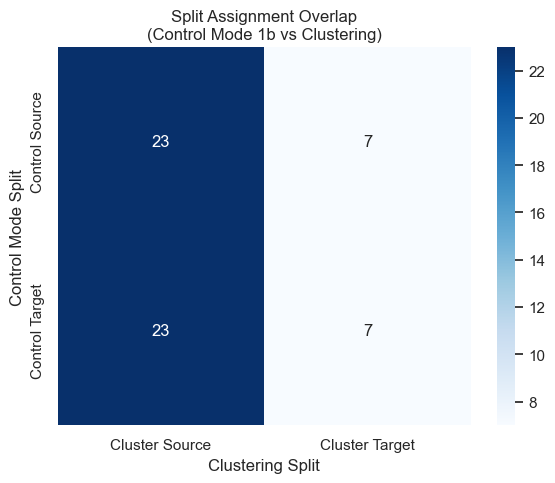

In [11]:
# Visualize overlap as confusion matrix
control_source_set = set(control_split['source'])
control_target_set = set(control_split['target'])
cluster_source_set = set(cluster_split['source'])
cluster_target_set = set(cluster_split['target'])

# Create confusion matrix
cm = np.array([
    [len(control_source_set & cluster_source_set), len(control_source_set & cluster_target_set)],
    [len(control_target_set & cluster_source_set), len(control_target_set & cluster_target_set)]
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Cluster Source', 'Cluster Target'],
            yticklabels=['Control Source', 'Control Target'])
ax.set_title('Split Assignment Overlap\n(Control Mode 1b vs Clustering)')
ax.set_xlabel('Clustering Split')
ax.set_ylabel('Control Mode Split')

plt.tight_layout()
plt.savefig('../outputs/figures/split_overlap.png', dpi=150)
plt.show()

## 5. Save Split Assignments

In [12]:
# Save assignments to JSON
assignments = save_split_assignments(control_variant="1b")
print("Saved split_assignments.json")
print("\nAssignments summary:")
print(f"  Control mode source: {len(assignments['control_mode']['source'])} batches")
print(f"  Control mode target: {len(assignments['control_mode']['target'])} batches")
print(f"  Clustering source: {len(assignments['clustering']['source'])} batches")
print(f"  Clustering target: {len(assignments['clustering']['target'])} batches")

Saved split_assignments.json

Assignments summary:
  Control mode source: 30 batches
  Control mode target: 30 batches
  Clustering source: 71 batches
  Clustering target: 19 batches


## Summary

**Split 1 (Control Mode - variant 1b):**
- Source: Batches 1-30 (Recipe-driven)
- Target: Batches 61-90 (APC/Raman-based)

**Split 2 (Data-driven Clustering):**
- K-means on early-window (25%) features: DO2 and Fs statistics
- Clusters based on process behavior patterns

**Observations:**
- PCA/t-SNE shows separation between clusters
- Overlap analysis reveals relationship between control mode and data-driven clusters